#DS-002: Customer Journey & Conversion Funnel Analysis

## Difficulty: Medium-Hard

## Estimated Time: 4–5 hours

## Interview Focus:

- Pandas proficiency
- Product analytics
- Business reasoning
- Clean notebook organization
- Communicating recommendations

## Background

You are a Product Data Scientist supporting the growth team for a large e-commerce marketplace.

Leadership has noticed that conversion has plateaued, despite traffic continuing to increase.

They want to understand:

- Where customers drop out
- Which customer segments convert best
- Whether different product categories have different purchase funnels
- What opportunities exist to improve conversion

In [1]:
import pandas as pd
import numpy as np
import duckdb
import uuid
import datetime as dt
from src.preprocess import *
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [2]:
# Notebook display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 2)

In [3]:
con = duckdb.connect('datasets/ecommerce.db')

october = con.read_csv('datasets/2019-Oct.csv', header=True)
october.create('october')
november = con.read_csv('datasets/2019-Nov.csv', header=True)
november.create('november')
con.execute('create table ecommerce as select * from october union all select * from november')

For testing purposes, let's start by only looking at the first two weeks of October

In [4]:
conversions = con.execute("select * from ecommerce where event_time < DATE'2019/10/14' and event_type='purchase'").df()
conversions.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:02:14,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,543272936,8187d148-3c41-46d4-b0c0-9c08cd9dc564
1,2019-10-01 00:04:37,purchase,1002532,2053013555631882655,electronics.smartphone,apple,642.69,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68
2,2019-10-01 00:06:02,purchase,5100816,2053013553375346967,NaN,xiaomi,29.51,514591159,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56
3,2019-10-01 00:07:07,purchase,13800054,2053013557418656265,furniture.bathroom.toilet,santeri,54.42,555332717,1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f
4,2019-10-01 00:09:26,purchase,4804055,2053013554658804075,electronics.audio.headphone,apple,189.91,524601178,2af9b570-0942-4dcd-8f25-4d84fba82553


#ok - We'll look at these 5 conversions to see what the funnel looks like.  These are user sessions
'8187d148-3c41-46d4-b0c0-9c08cd9dc564', '3c80f0d6-e9ec-4181-8c5c-837a30be2d68', '0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56', '1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f', '2af9b570-0942-4dcd-8f25-4d84fba82553' 

In [5]:
sessions = con.execute("""select * from ecommerce where user_session in 
('8187d148-3c41-46d4-b0c0-9c08cd9dc564', '3c80f0d6-e9ec-4181-8c5c-837a30be2d68', 
'0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56', '1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f', 
'2af9b570-0942-4dcd-8f25-4d84fba82553')
ORDER BY user_session, event_time""").df()
sessions

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:04:02,view,5100816,2053013553375346967,NaN,xiaomi,29.51,514591159,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56
1,2019-10-01 00:06:02,purchase,5100816,2053013553375346967,NaN,xiaomi,29.51,514591159,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56
2,2019-10-01 00:06:00,view,13800054,2053013557418656265,furniture.bathroom.toilet,santeri,54.42,555332717,1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f
3,2019-10-01 00:07:07,purchase,13800054,2053013557418656265,furniture.bathroom.toilet,santeri,54.42,555332717,1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f
4,2019-10-01 00:06:31,view,4804055,2053013554658804075,electronics.audio.headphone,apple,189.91,524601178,2af9b570-0942-4dcd-8f25-4d84fba82553
5,2019-10-01 00:09:26,purchase,4804055,2053013554658804075,electronics.audio.headphone,apple,189.91,524601178,2af9b570-0942-4dcd-8f25-4d84fba82553
6,2019-10-01 00:09:54,view,4804055,2053013554658804075,electronics.audio.headphone,apple,189.91,524601178,2af9b570-0942-4dcd-8f25-4d84fba82553
7,2019-10-01 00:01:45,view,1003305,2053013555631882655,electronics.smartphone,apple,612.43,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68
8,2019-10-01 00:02:08,view,1002528,2053013555631882655,electronics.smartphone,apple,643.23,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68
9,2019-10-01 00:02:47,view,1002532,2053013555631882655,electronics.smartphone,apple,642.69,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68


Ok.  From these sessions, it looks like our funnel should be organized by product within session as opposed to session.  I'm also a little confused about the lack of the cart step of the funnel in any of these user journeys.  Let's look at the different users and see what a single user behavior over multiple sessions might look like.

In [6]:
users = con.sql("""SELECT * FROM ecommerce WHERE user_id = 514591159 ORDER BY user_id, event_time, user_session""").df()
#pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')
users

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:04:02,view,5100816,2053013553375346967,NaN,xiaomi,29.51,514591159,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56
1,2019-10-01 00:06:02,purchase,5100816,2053013553375346967,NaN,xiaomi,29.51,514591159,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56
2,2019-10-01 17:21:06,view,5100328,2053013553341792533,electronics.clocks,xiaomi,117.88,514591159,ff5b5a74-1d63-4bad-903a-d9b12c3820b9
3,2019-10-04 07:49:25,view,5100816,2053013553375346967,NaN,xiaomi,28.56,514591159,fd57160a-dfbf-4d68-92da-cee6104d0a7e
4,2019-10-05 11:26:05,view,5100328,2053013553341792533,electronics.clocks,xiaomi,117.83,514591159,e2966da4-ece4-476a-921a-110828f7b5ee
...,...,...,...,...,...,...,...,...,...
98,2019-11-30 12:09:24,view,36600038,2070747671722722162,NaN,NaN,97.79,514591159,774bba29-fbd3-43ed-a0ac-4646c1ee5a7e
99,2019-11-30 12:10:12,view,36600033,2070747671722722162,NaN,NaN,167.55,514591159,af8e32ec-8c3d-4961-b2e3-865c140c574b
100,2019-11-30 12:11:40,view,100018521,2070747671722722162,NaN,satura,64.35,514591159,af8e32ec-8c3d-4961-b2e3-865c140c574b
101,2019-11-30 12:12:04,view,36600062,2070747671722722162,NaN,NaN,81.83,514591159,af8e32ec-8c3d-4961-b2e3-865c140c574b


Ok.  The above was a false assumption.  Let's organize the funnel by product within user.  We notice that some of these purchases do not have a cart event immediately before the purchase.  This might be due to a lag between viewing and purchasing.  We will start by generating a series of user journeys for each user/product pair, and will then aggregate those
for further analysis.

In [131]:
# create journeys
con.sql("""
CREATE OR REPLACE TABLE journeys AS SELECT *,
SUM(case when event_type = 'purchase' then 1 else 0 end)
OVER (PARTITION BY user_id, product_id ORDER BY event_time 
RANGE BETWEEN CURRENT ROW
              AND INTERVAL '30 days' FOLLOWING) AS journey_num
from ecommerce
""")

In [132]:
con.sql("UPDATE journeys SET journey_num = journey_num - 1 WHERE event_type='purchase'")
con.sql("ALTER TABLE journeys ADD COLUMN IF NOT EXISTS converted BOOL DEFAULT false")
con.sql("UPDATE journeys SET journey_id = CONCAT(user_id,'-',product_id,'-',journey_num)")
con.sql("UPDATE journeys SET converted = TRUE WHERE journey_id IN (select journey_id FROM journeys WHERE event_type='purchase')")

In [133]:
con.sql("SELECT * FROM journeys LIMIT 100").df()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,journey_id,journey_num,converted
0,2019-10-01 11:24:30,view,42300060,2095518921321874323,furniture.living_room.cabinet,NaN,120.96,524711196,b769122b-bc80-4938-9ed6-b2fda93e7dac,524711196-42300060-0,0.0,False
1,2019-11-10 12:40:01,view,2702565,2053013563911439225,appliances.kitchen.refrigerators,dauscher,638.09,524711339,1ff0346c-1942-4c8a-b4b7-107e8fe12617,524711339-2702565-0,0.0,False
2,2019-10-18 13:21:08,view,2500535,2053013564003713919,appliances.kitchen.oven,whirlpool,416.72,524711397,a04c5ad9-2d88-4753-b6c9-670efb42261e,524711397-2500535-0,0.0,False
3,2019-10-13 02:01:11,view,24300118,2053013563248739153,NaN,NaN,17.97,524711397,a5834e7f-351c-48f8-90b0-e1a103948947,524711397-24300118-0,0.0,False
4,2019-10-13 05:59:39,view,24300118,2053013563248739153,NaN,NaN,17.97,524711397,8dc29ed1-d662-42e9-9049-0e124ca2ee7c,524711397-24300118-0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
95,2019-10-24 04:43:36,view,2900958,2053013554776244595,appliances.kitchen.microwave,arg,56.60,524718276,4dbb1ffb-4f96-4ca2-ace1-c6c66afd142f,524718276-2900958-0,0.0,False
96,2019-10-27 07:39:07,view,2900958,2053013554776244595,appliances.kitchen.microwave,arg,56.60,524718276,484daf8c-87e1-4573-aa9b-c2b085e075b4,524718276-2900958-0,0.0,False
97,2019-10-27 07:39:21,view,2900958,2053013554776244595,appliances.kitchen.microwave,arg,56.60,524718276,484daf8c-87e1-4573-aa9b-c2b085e075b4,524718276-2900958-0,0.0,False
98,2019-11-07 09:53:35,view,2900958,2053013554776244595,appliances.kitchen.microwave,arg,56.60,524718276,dd3344f6-b6fc-4de1-94bc-9a3aae3b6b39,524718276-2900958-0,0.0,False


In [134]:
con.sql('select * from journeys where converted=TRUE limit 10').df()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,journey_id,journey_num,converted
0,2019-11-17 14:28:22,purchase,1004659,2053013555631882655,electronics.smartphone,samsung,762.18,524712215,c1310bfa-37fb-4114-a54b-772f318ba653,524712215-1004659-1,1.0,True
1,2019-11-17 14:28:55,view,1004659,2053013555631882655,electronics.smartphone,samsung,762.18,524712215,c1310bfa-37fb-4114-a54b-772f318ba653,524712215-1004659-1,1.0,True
2,2019-11-17 14:29:29,view,1004659,2053013555631882655,electronics.smartphone,samsung,762.18,524712215,c1310bfa-37fb-4114-a54b-772f318ba653,524712215-1004659-1,1.0,True
3,2019-11-17 14:29:34,cart,1004659,2053013555631882655,electronics.smartphone,samsung,762.18,524712215,c1310bfa-37fb-4114-a54b-772f318ba653,524712215-1004659-1,1.0,True
4,2019-11-17 14:29:42,cart,1004659,2053013555631882655,electronics.smartphone,samsung,762.18,524712215,c1310bfa-37fb-4114-a54b-772f318ba653,524712215-1004659-1,1.0,True
5,2019-11-17 14:30:03,purchase,1004659,2053013555631882655,electronics.smartphone,samsung,762.18,524712215,c1310bfa-37fb-4114-a54b-772f318ba653,524712215-1004659-0,0.0,True
6,2019-11-17 14:31:01,view,1004659,2053013555631882655,electronics.smartphone,samsung,762.18,524712215,c1310bfa-37fb-4114-a54b-772f318ba653,524712215-1004659-0,0.0,True
7,2019-10-09 03:33:15,purchase,4300149,2053013552385491165,NaN,polaris,33.43,524720754,8bf532a9-c7c3-403a-8b6c-1a333ccbcce3,524720754-4300149-0,0.0,True
8,2019-10-13 07:35:04,purchase,26300032,2053013563584283495,NaN,lucente,122.27,524731203,f3805db2-f779-4423-a7eb-fc9c3123827d,524731203-26300032-0,0.0,True
9,2019-10-13 07:35:28,view,26300032,2053013563584283495,NaN,lucente,122.27,524731203,f3805db2-f779-4423-a7eb-fc9c3123827d,524731203-26300032-0,0.0,True


We have now defined our user journeys and whether or they compute.  Now I'm going to analyze to see the number of user sessions per journey, the price of the item
per journey, and the length (in days) for each journey to see if there is any correlation between that type of activity and conversion.

In [8]:
def side_by_side_hist(positive: pd.DataFrame, negative: pd.DataFrame, column: str, title=''):
    plt.figure()
    plt.subplot(1,2,1)
    plt.hist(positive[column], bins=30, log='y')
    plt.title(title + ' - Converted')
    plt.ylabel(column)

    plt.subplot(1,2,2)
    plt.hist(negative[column], bins=30, log='y')
    plt.title(title + ' - Not Converted')
    plt.ylabel(column)

    return plt

In [5]:
# user sessions per journey
sessions_per_journey = con.sql("select journey_id, count(distinct(user_session)) as sessions, first(converted) as converted from journeys group by journey_id").df()
sessions_per_journey.head()
spj_converted = sessions_per_journey.loc[sessions_per_journey.converted == True,]
spj_uncov = sessions_per_journey.loc[sessions_per_journey.converted == False,]

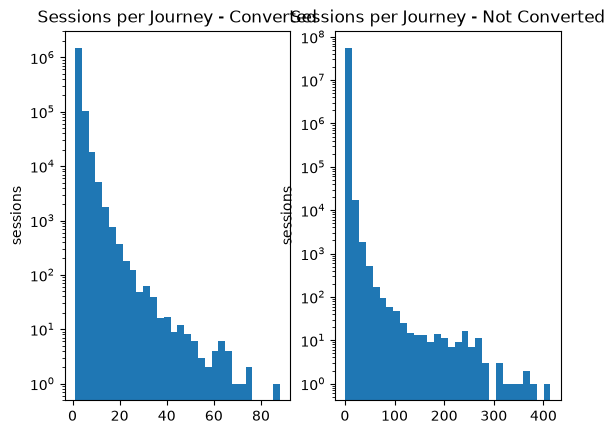

In [9]:
test = side_by_side_hist(spj_converted, spj_uncov, 'sessions', 'Sessions per Journey')
test.show()

In [12]:
ttest_ind(spj_converted['sessions'], spj_uncov['sessions'])

TtestResult(statistic=np.float64(766.0802650282357), pvalue=np.float64(0.0), df=np.float64(58012487.0))

In [13]:
print(spj_converted['sessions'].mean())
print(spj_uncov['sessions'].mean())

1.7822684505102528
1.214628763771679


Looking at the number of sessions per journey, we see that a larger number of sessions (longer engagement with the site over time) will lead
to a higher conversion.  This is a statistically significant result - although not entirely surprising.  These would be individuals who looked at the item, then thought about it and came back.  This might indicate that some amount of retargeting or reminders might assist in avoiding abandoned potential purchases.

In [14]:
# clear memory
del(spj_converted)
del(spj_uncov)
del(sessions_per_journey)

In [21]:
# price per journey data pull
price_per_journey = con.sql("select journey_id, min(price) as min_price, max(price) as max_price, avg(price) as avg_price, max(price)-min(price) as price_delta, first(converted) as converted from journeys group by journey_id").df()
price_per_journey.head()

,journey_id,min_price,max_price,avg_price,price_delta,converted
0,536908150-3601290-0,210.79,210.79,210.79,0.0,False
1,536918037-4200544-0,231.07,231.07,231.07,0.0,False
2,536925177-1003311-0,705.04,705.04,705.04,0.0,True
3,536928832-28715177-0,75.68,75.68,75.68,0.0,False
4,536999659-1003317-1,965.02,965.02,965.02,0.0,False


In [22]:
ppj_converted = price_per_journey.loc[price_per_journey.converted == True,]
ppj_uncov = price_per_journey.loc[price_per_journey.converted == False,]

In [32]:
price_per_journey.loc[price_per_journey.price_delta > 0,].sort_values('price_delta', desc=True).tail(30)

TypeError: DataFrame.sort_values() got an unexpected keyword argument 'desc'

In [26]:
price_per_journey.price_delta.describe()

count    5.80e+07
mean     9.25e-01
std      1.22e+01
min      0.00e+00
25%      0.00e+00
50%      0.00e+00
75%      0.00e+00
max      2.57e+03
Name: price_delta, dtype: float64

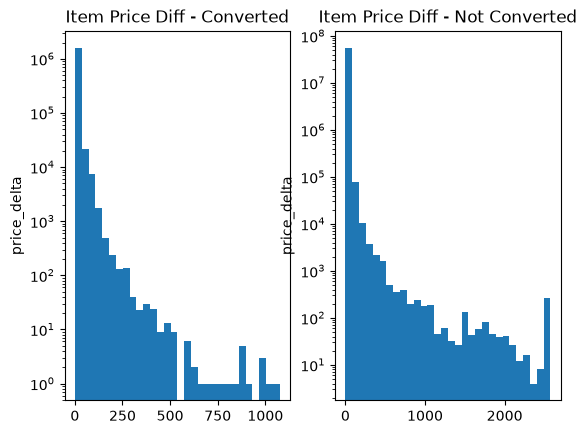

In [27]:
test = side_by_side_hist(ppj_converted, ppj_uncov, 'price_delta', 'Item Price Diff')
test.show()

In [28]:
print(ttest_ind(ppj_converted['price_delta'], ppj_uncov['price_delta']))
print(ppj_converted['price_delta'].mean())
print(ppj_uncov['price_delta'].mean())

TtestResult(statistic=np.float64(149.3409935329478), pvalue=np.float64(0.0), df=np.float64(58012487.0))
2.328610049709456
0.8844478237386868


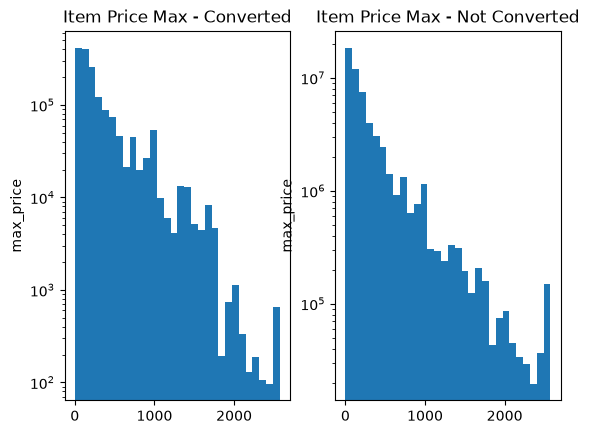

In [29]:
test = side_by_side_hist(ppj_converted, ppj_uncov, 'max_price', 'Item Price Max')
test.show()

In [30]:
print(ttest_ind(ppj_converted['max_price'], ppj_uncov['max_price']))
print(ppj_converted['max_price'].mean())
print(ppj_uncov['max_price'].mean())

TtestResult(statistic=np.float64(56.90483513812997), pvalue=np.float64(0.0), df=np.float64(58012487.0))
304.40698253453195
287.7725755669155


We see several instances of a price being either updated or potentially missing values at some point during user journeys.  These instances also seem to be less likely to convert.  We can see from our comparisons of price delta (maximum price during journey - min price during journey) that when there is a difference in price, there is a decrease in conversion rate.  Further analysis is needed to show whether or not these are price increases or price decreases that drive this behavior.

However, looking at strictly the maximum price, we can see that conversions (on average) did happen on higher priced items.  I would not recommend raising prices because of that however.  It is possible that this is due to a mix of missing prices (which would fall out as 0 cost) or our consumers having a preferenced for higher-priced items.  Further analysis is definitely required.

In [33]:
del(price_per_journey)
del(ppj_converted)
del(ppj_uncov)

In [4]:
# time per journey data pull
time_per_journey = con.sql("select journey_id, epoch(max(event_time)-min(event_time)) as time_length, first(converted) as converted from journeys group by journey_id").df()
time_per_journey.head()

,journey_id,time_length,converted
0,524748774-1005129-0,0.00e+00,False
1,524763101-12718088-0,0.00e+00,False
2,524807961-5701062-0,5.60e+01,False
3,524808325-1004238-0,2.59e+06,False
4,524816053-12718062-0,0.00e+00,False


In [6]:
tpj_converted = time_per_journey.loc[time_per_journey.converted == True,]
tpj_uncov = time_per_journey.loc[time_per_journey.converted == False,]

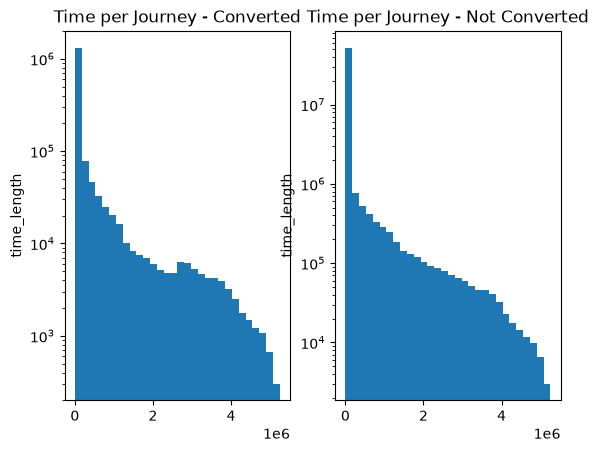

In [9]:
test = side_by_side_hist(tpj_converted, tpj_uncov, 'time_length', 'Time per Journey')
test.show()

In [12]:
print(ttest_ind(tpj_converted['time_length'], tpj_uncov['time_length']))
print(tpj_converted['time_length'].mean())
print(tpj_uncov['time_length'].mean())

TtestResult(statistic=np.float64(442.7607315201648), pvalue=np.float64(0.0), df=np.float64(58012487.0))
240602.2164576649
89891.72161436005


From the analysis of total length of time over the journey, we see that conversions tend to happen from a longer user journey than not.  This is, once again, not unexpected, as "window shoppers" will have minimal user journey time (potentially 0).  Once again, redirections and reminders might help to move individuals through the funnel.

# Summary

In this notebook, we have converted our data into a duckdb database for somewhat faster processing.  We also generated a new table `journeys` that calls out individual user/product journeys.  We have defined a journey as one combination of a user looking at an individual product that may or may not lead to a purchase.  Once a purchase takes place, if the user then views that item again, it is considered to be a new journey.

Although it was not explored yesterday, we did notice some instances where prices were missing in the dataset.  While we did not attempt to impute or otherwise correct these values, we did notice them in our analysis - we left them as is.

In this particular analysis, we strictly examined the effect of price (maximum price and price delta) across the possibility of conversion, the number of sessions within a user journey against conversion, and the total time of a user journey against conversion.  While there are many other aspects to study (which will be referenced later), these are the ones that were possible within the alloted time.

## Price vs Conversion

We looked at two aspects of price on conversion - price delta (difference in minimum and maximum price) and the overall maximum price.

### Price delta

We were intererested to see if there was any impact on missing prices (or price changes during the user journey) on conversions.  We found that a higher price delta was indicative of lower conversions.  Based on this analysis, I would recommend that prices be kept constant as much as possible.

That being said, there is further work that can be done in terms of cleaning the data set (dealing with 0 prices) and analysis of whether price increases or price decreases have any impact on conversion rates.

### Max price

We noticed that those user journeys that eneded in conversion dealt with higher maximum prices than those that did not.  I would strongly recommend further study in this area, as this is somewhat counter-intuitive.  It is possible that this is some sort of recognition of our site being safer to buy higher-ticket items.  I would definitely *not* recommend raising prices due to this result without significant further study.

## User sessions vs conversion

Looking at the number of user sessions for each conversion, we saw an increase in conversions correlated with an increase in user sessions.  This might indicate that our products are ones where users need to view, think about, and then come back.  Once again, this matches with the potential signal in higher prices and the user behavior of wanting to do research on their purchase and then come back as opposed to impulse purchases.

## Journey time vs conversions

The total journey time is similar to the number of user sessions per conversion.  We see longer journey times correlated with conversions.  This would lead to a recommendataion of implementing a redirection or reminder system to avoid cart abandonment.

## Further Study

### Missing funnel stages
As we were building out our journeys, we noticed a number of instances where the product was viewed and then immediately purchased.  This bears further study, which was not done at this time.  Some possibilities for this are 
 1. Log failure (event not caught)
 2. Added to cart in previous session or prior in journey

Getting to the bottom of this will take further analysis of user journeys where we would examine how often each type of these effects occur.

### Funnel progression

Another potential aspect of future study is the rate of progression through the sales funnel.  Since we have three different funnel stages, we can calculate out the rate at which journeys fail to pass from one stage of the funnel to the next.  That would assist us in potentially determining where to adjust the site in order to improve our overall conversion rates.

### Price delta

We noticed several instances of changing price on the site.  Futher study is needed to determine whether these price changes are real and whether or not an increase in price versus a decrease in price vs any price change is impactful on conversions.  This could directly impact business strategy going forward.

## Recommendations

We have several recommendations that we can pull from just this short analysis:

1. Implement a redirection or reminder system after the journey has been dormant for a certain amount of time.  This will help to bring users back to the site and re-engage them in the sales funnel.
2. Keep prices steady and double-check to make sure that missing prices in the data are not representative of missing/out of stock information on the site itself.  Large changes in price seem to be harmful to conversions



# Product Sense
## Facebook Marketplace introduces an "Instant Buy" button to allow users to purchase with a single tap instead of going through the cart flow

To determine whether or not this feature is successful, we need to define which metrics are most essential to monitor.

## Success Metric(s):
1. Total transactions - with less friction on transactions, customers are more likely to finish transactions

## North Star:
1. Monthly transactions - we want this to continue to grow

## Guardrail metrics:
1. MAU - we don't want to lose consumers
2. Active listings - we don't want to lose listers

## Experiment design
Since this is more of a marketplace as opposed to a networking situation, we should be ok with doing a 50/50 split of treatment vs control groups.  This will give us the best power for our test.  The test should run for at least 2 weeks (longer would be better, but business decision might require a faster result).  Running for 2 weeks will grant views into weekly seasonality.  I don't believe we will need to run long enough to worry about yearly seasonality issues for this particular experiment.

## Hypotheses:
H_0: There is no impact on transactions from implementing the new feature
H_A: There is a positive impact on transactions to implementing the new feature

## Success criteria
We need to determine what an acceptable increase in our metrics will consititute a successful test.  We will arbitrarily assume a 3% increase in total transactions as our success criteria.

### Sample size
We will assume the standard alpha=0.05 (probability of accepting the alternative hypothesis given that the null is actually true) and power (1-beta) = 0.8 (20% chance of not seeing a real impact and assuming the null hypothesis is true).

We can assume historical variances for our metrics and can use standard formulas for calculating sample size.

### Segments
For this, we might need to break down our customer segments into high-volume and low-volume buyers.  We can also examine local (pick-up) vs remote (shipped) transactions to see if there
is any difference.

## Ramp
I would set a ramp-up by starting with 10% of our expected final percentage of users for 48 hours.  This will give us time to make sure there are no bugs in the implementation.  After the 48 hours proving time, we would open it to the remainder of the population.

## Decision criteria
In order to move forward with the new feature, we would want to calculate a t-test between the treatment and control groups.  If the p-value of this t-test (corrected for however many tests and/or groups are being examined) is below our significance level (0.05), then we would assume that the "Instant Buy" button has generated an increased number of transactions and allow global implementation.

If we do not have time to generate the full sample size, then a Bayesian-style test may be more useful, as we can check the result on a more regular basis without compromising the integrity of the test.  We would do this by calculating the posterior distribution of each of the test and control samples and look for a lack of overlap in the "confidence intervals" of these two distributions.  If the overlap goes to 0, we can safely assume that the treatment has had an effect.